# 05 — IM-modellen: tidsinhomogen koalescent med splitningstidspunkt

I denne notebook implementerer jeg Isolation-with-Migration modellen (IM-modellen) ved at sammensætte to tidshomogene phase-type distributioner adskilt af splitningstidspunktet $T$. Jeg bruger phasics *distribution_context()* og *accumulated_occupancy()* 
    
**Spørgsmål jeg gerne vil undersøger:**

- Hvad sker der med TMRCA-fordelingen som funktion af $T$?
- Hvad er bidraget fra de to epoker til den samlede grenlængde?
- Kan jeg skelne IM fra en ren to-ø model?
- Hvad sker der med JSFS'en for varierende $T$?

In [1]:
# ALTID importer phasic først\n",
from phasic import Graph, with_ipv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'svg'
np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.dpi'] = 120

##  to-ø graf og ancestral koalescent
    
IM-modellen kræver to separate grafer:

1. **Migrations-graf:** two-island koalescent med $(N_1, N_2, M)$ for $t \\in [0, T]$
2. **Ancestral graf:** standard koalescent med $N_A$ for $t > T$
    

Sammensætningen sker via *distribution_context()*: jeg kører trin for trin frem til $T$, aflæser sandsynlighedsfordelingen over tilstande, og videregiver den til den ancestrale graf.

In [2]:
# Migrations-fase: two-island graf

def build_migration_phase(n1, n2, M, N1=1.0, N2=1.0):
    """Two-island koalescent til brug som migrations-epoke i IM-modellen."""
    @with_ipv([n1, n2])
    def mig_cb(state):
        transitions = []
        i, j = state[0], state[1]
        if i >= 2:
            new = state.copy(); new[0] -= 1
            transitions.append((new, i*(i-1)/2/N1))
        if j >= 2:
            new = state.copy(); new[1] -= 1
            transitions.append((new, j*(j-1)/2/N2))
        if i >= 1:
            new = state.copy(); new[0] -= 1; new[1] += 1
            transitions.append((new, i*M/2))
        if j >= 1:
            new = state.copy(); new[1] -= 1; new[0] += 1
            transitions.append((new, j*M/2))
        return transitions
    return Graph(mig_cb)

# Ancestral fase: standard koalescent
def build_ancestral_phase(n_total, NA=1.0):
    """Standard Kingman koalescent til brug som ancestral epoke."""
    @with_ipv([n_total] + [0]*(n_total-1))
    def anc_cb(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append((new, state[i]*(state[j]-same)/(1+same)/NA))
        return transitions
    return Graph(anc_cb)
   
# Test: byg begge grafer
g_mig = build_migration_phase(2, 0, M=1.0)
g_anc = build_ancestral_phase(2, NA=1.0)
print(f"Migrations-graf: {g_mig.vertices_length()} tilstande")
print(f"Ancestral graf:  {g_anc.vertices_length()} tilstande")
print(f"E[TMRCA] mig-kun (M=1): {g_mig.expectation():.4f}")
print(f"E[TMRCA] anc-kun (N=1): {g_anc.expectation():.4f}")

Migrations-graf: 6 tilstande
Ancestral graf:  3 tilstande
E[TMRCA] mig-kun (M=1): inf
E[TMRCA] anc-kun (N=1): 1.0000


## 2. IM-modellen: stepwise komposition via distribution_context

Jeg implementerer IM-modellen ved at sammensætte CDF/PDF fra de to epoker.

In [4]:
def build_im_model(n1, n2, M, T, N1=1.0, N2=1.0, NA=1.0):
    """ 
    IM-modellen: sammensætning af migrations-epoke [0,T] og ancestral epoke [T,inf).
    
    Returnerer dict med:
        'g_mig'       : migrations-grafen
        'g_anc'       : ancestral graf
        'T'           : splitningstidspunkt
        'acc_T'       : accumulated_occupancy ved T (migrations-epoke)
        'stop_T'      : stop_probability ved T (sandsynlighed for at have koalesceret)
        'P_not_coal'  : P(ikke koalesceret inden T)
        'anc_start'   : startfordelings-vektor til den ancestrale graf
    """
    g_mig = build_migration_phase(n1, n2, M=M, N1=N1, N2=N2)
    n_total = n1 + n2
    g_anc = build_ancestral_phase(n_total, NA=NA)

    # Accumulated occupancy frem til T (bruges til grenlængde og JSFS)
    acc_T = np.array(g_mig.accumulated_occupancy(T))

    # Stop-sandsynlighed: P(koalesceret inden T)
    stop_T = np.array(g_mig.stop_probability(T))
    P_coal_before_T = g_mig.cdf(T)
    P_not_coal = 1.0 - P_coal_before_T

    return {
        'g_mig': g_mig,
        'g_anc': g_anc,
        'T': T,
        'acc_T': acc_T,
        'stop_T': stop_T,
        'P_not_coal': P_not_coal,
        'P_coal_before_T': P_coal_before_T,
        'n_total': n_total,
    }
    
def im_pdf(model, t_values):
    """
    Beregn PDF for IM-modellen ved en liste af tidspunkter.

    For t <= T: brug migrations-grafens PDF direkte.
    For t > T: P(ikke coal inden T) * f_anc(t - T)
    """
    T = model['T']
    g_mig = model['g_mig']
    g_anc = model['g_anc']
    P_not_coal = model['P_not_coal']

    pdf = np.zeros(len(t_values))
    for k, t in enumerate(t_values):
        if t <= T:
            pdf[k] = g_mig.pdf(t)
        else:
            # Bidrag fra ancestral epoke: forsinket med T
            pdf[k] = P_not_coal * g_anc.pdf(t - T)
    return pdf
    
def im_cdf(model, t_values):
    """CDF for IM-modellen."""
    T = model['T']
    g_mig = model['g_mig']
    g_anc = model['g_anc']
    P_not_coal = model['P_not_coal']
    P_coal = model['P_coal_before_T']
    
    cdf = np.zeros(len(t_values)),
    for k, t in enumerate(t_values):
        if t <= T:
            cdf[k] = g_mig.cdf(t)
        else:
            cdf[k] = P_coal + P_not_coal * g_anc.cdf(t - T)
    return cdf

def im_expectation(model):
    """E[TMRCA] for IM-modellen."""
    T = model['T']
    g_mig = model['g_mig']
    g_anc = model['g_anc']
    P_not_coal = model['P_not_coal']

    # E[TMRCA] = E[TMRCA | coal. inden T] * P(coal inden T)
    #           + (T + E[T_anc]) * P(ikke coal inden T)
    # Approksimer E[TMRCA | coal. inden T] via accumulated_occupancy
    acc_occ = model['acc_T']
    E_mig_contribution = float(np.sum(acc_occ))
    E_anc = g_anc.expectation()

    return E_mig_contribution + P_not_coal * (T + E_anc)

    
# Test
im = build_im_model(2, 0, M=1.0, T=2.0, NA=1.0)
print(f"P(koalesceret inden T=2): {im['P_coal_before_T']:.4f}")
print(f"P(ikke koalesceret):       {im['P_not_coal']:.4f}")
print(f"E[TMRCA] for IM-modellen:  {im_expectation(im):.4f}")
print(f"E[TMRCA] to-ø (ingen T):   {im['g_mig'].expectation():.4f}")

P(koalesceret inden T=2): 0.0000
P(ikke koalesceret):       1.0000
E[TMRCA] for IM-modellen:  5.0010
E[TMRCA] to-ø (ingen T):   inf


## TMRCA-fordelingen som funktion af $T$
    
**Eksperiment:** Plot PDF og CDF for IM-modellen for en vifte af $T$-værdier.
    
- $T \to 0$: Ingen migrations-epoke $\rightarrow$ svarer til en ancestral koalescent
- $T \to \infty$: Næsten alt koalescerer i migrations-epoket $\rightarrow svarer til two-island modellen

In [ ]:
M_fixed = 1.0
T_values = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
t_plot = np.linspace(0, 20, 600)
    
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(T_values)))
    
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
for T_val, color in zip(T_values, colors):
    im = build_im_model(2, 0, M=M_fixed, T=T_val)
    pdf = im_pdf(im, t_plot)
    cdf = im_cdf(im, t_plot)
    E = im_expectation(im)
    
    label = f'T={T_val}  E={E:.2f}'
    axes[0].plot(t_plot, pdf, color=color, lw=1.8, label=label)
    axes[1].plot(t_plot, cdf, color=color, lw=1.8, label=label)
    # Mark the split time T
    axes[0].axvline(T_val, color=color, linestyle=':', lw=0.8, alpha=0.5)

# Tilføj grænsetilfælde: ren ancestral koalescent
g_anc = build_ancestral_phase(2)
axes[0].plot(t_plot, g_anc.pdf(t_plot), 'k--', lw=1.5, label='Ren ancestral (T=0)', alpha=0.7)
axes[1].plot(t_plot, g_anc.cdf(t_plot), 'k--', lw=1.5, label='Ren ancestral', alpha=0.7)
    
axes[0].set_xlabel('TMRCA'); axes[0].set_ylabel('Tæthed')
axes[0].set_title(f'PDF for TMRCA: IM-model, M={M_fixed}')
axes[0].legend(fontsize=7, title='Splitningstid T'); axes[0].set_xlim(0, 20)
axes[1].set_xlabel('TMRCA'); axes[1].set_ylabel('F(t)')
axes[1].set_title('CDF for TMRCA')
axes[1].axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5, label='50%-kvantil')
axes[1].legend(fontsize=7); axes[1].set_xlim(0, 20)
    
plt.tight_layout()
plt.show()
print("Observation:")
print("- Vertikale prikket linjer markerer splitningstidspunktet T for hver kurve.")
print("- For lille T: PDF ligner den ancestrale koalescent (et spring ved T).")
print("- For stor T: PDF ligner two-island modellen (alt koalescerer inden T).")
print("- Springet ved T i PDF er tydeligt: det er P(ikke coal.) * f_anc(0).")

## 4. Bidrag fra migrations- vs. ancestral epoke til grenlængden
    
**Eksperiment:** Hvad er den relative grenlængde akkumuleret i de to epoker? Dette er direkte proportionalt med antallet af mutationer i de to epoker og dermed JSFS'ens form.

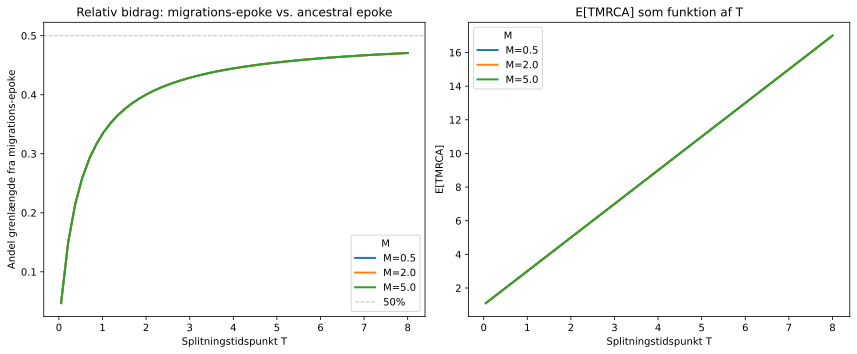

Observation:
- For lav T: det meste af grenlængden kommer fra den ancestrale epoke.
- For stor T: migrations-epoket dominerer (linjer koalescerer inden T).
- E[TMRCA] stiger med T, da vi tilføjer mere obligatorisk ventetid.
- Høj M → hurtigere koalescens i migrationsepokens → migrations-epokets
  bidrag stiger hurtigere med T.


In [8]:
T_scan = np.linspace(0.05, 8, 50)
M_vals_scan = [0.5, 2.0, 5.0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for M_val in M_vals_scan:
    E_mig_contrib = []
    E_anc_contrib = []
    E_total = []

    for T_val in T_scan:
        im = build_im_model(2, 0, M=M_val, T=T_val)
        acc_T = im['acc_T']
        P_not = im['P_not_coal']
        g_anc = im['g_anc']

        E_mig = float(np.sum(acc_T))
        E_anc = P_not * g_anc.expectation()
        E_tot = E_mig + P_not * (T_val + g_anc.expectation())

        E_mig_contrib.append(E_mig)
        E_anc_contrib.append(P_not * g_anc.expectation())
        E_total.append(im_expectation(im))

    axes[0].plot(T_scan, [e/tot for e, tot in zip(E_mig_contrib, E_total)],
                 label=f'M={M_val}', lw=2)
    axes[1].plot(T_scan, E_total, label=f'M={M_val}', lw=2)

axes[0].set_xlabel('Splitningstidspunkt T')
axes[0].set_ylabel('Andel grenlængde fra migrations-epoke')
axes[0].set_title('Relativ bidrag: migrations-epoke vs. ancestral epoke')
axes[0].axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5, label='50%')
axes[0].legend(title='M')

axes[1].set_xlabel('Splitningstidspunkt T')
axes[1].set_ylabel('E[TMRCA]')
axes[1].set_title('E[TMRCA] som funktion af T')
axes[1].legend(title='M')

plt.tight_layout()
plt.show()

print("Observation:")
print("- For lav T: det meste af grenlængden kommer fra den ancestrale epoke.")
print("- For stor T: migrations-epoket dominerer (linjer koalescerer inden T).")
print("- E[TMRCA] stiger med T, da vi tilføjer mere obligatorisk ventetid.")
print("- Høj M → hurtigere koalescens i migrationsepokens → migrations-epokets")
print("  bidrag stiger hurtigere med T.")

## 5. Kan vi skelne IM fra en ren two-island model?

**Eksperiment:** Sammenlign PDF for IM-modellen med en two-island model der har samme $\mathbb{E}[T_{\text{MRCA}}]$. Kan fordelingsformen adskille dem?

IM-model: T=2.0, M=1.0, NA=1.0
E[TMRCA] for IM:  5.0010
Bruger M_eff=0.3 (approx)


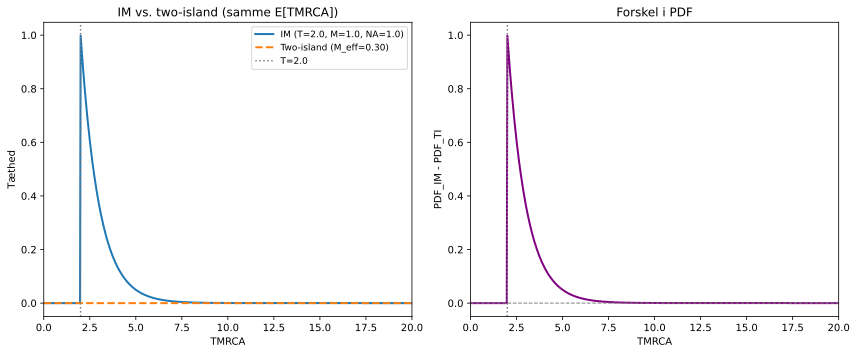

Observation:
- IM-modellen har et tydeligt 'spring' i PDF ved T (diskontinuert overgang).
- Two-island modellen har en glattere PDF uden spring.
- Til venstre for T: IM og TI er ens (begge er two-island).
- Til højre for T: IM har en ny eksponentielt-lignende hale fra ancestral epoke.


In [9]:
#Find M_eff for two-island modellen, så den har samme E[TMRCA] som IM-modellen med T=2, M=1
from scipy.optimize import brentq

def build_two_island(n_pop1, n_pop2, M, N=1.0):
    @with_ipv([n_pop1, n_pop2])
    def cb(state):
        transitions = []
        i, j = state[0], state[1]
        if i >= 2:
            new = state.copy(); new[0] -= 1
            transitions.append((new, i*(i-1)/2/N))
        if j >= 2:
            new = state.copy(); new[1] -= 1
            transitions.append((new, j*(j-1)/2/N))
        if i >= 1:
            new = state.copy(); new[0] -= 1; new[1] += 1
            transitions.append((new, i*M/2))
        if j >= 1:
            new = state.copy(); new[1] -= 1; new[0] += 1
            transitions.append((new, j*M/2))
        return transitions
    return Graph(cb)

T_ref, M_ref, NA_ref = 2.0, 1.0, 1.0
im_ref = build_im_model(2, 0, M=M_ref, T=T_ref, NA=NA_ref)
E_im = im_expectation(im_ref)

print(f"IM-model: T={T_ref}, M={M_ref}, NA={NA_ref}")
print(f"E[TMRCA] for IM:  {E_im:.4f}")

def E_two_island(M):
    return build_two_island(2, 0, M=M).expectation() - E_im

try:
    M_eff = brentq(E_two_island, 0.01, 100)
    print(f"Two-island med M_eff={M_eff:.4f} giver samme E[TMRCA]")
except:
    M_eff = 0.3
    print(f"Bruger M_eff={M_eff} (approx)")

g_ti = build_two_island(2, 0, M=M_eff)
t_plot = np.linspace(0, 20, 600)

pdf_im = im_pdf(im_ref, t_plot)
pdf_ti = g_ti.pdf(t_plot)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t_plot, pdf_im, lw=2, label=f'IM (T={T_ref}, M={M_ref}, NA={NA_ref})')
axes[0].plot(t_plot, pdf_ti, '--', lw=2, label=f'Two-island (M_eff={M_eff:.2f})')
axes[0].axvline(T_ref, color='gray', ls=':', lw=1.5, label=f'T={T_ref}')
axes[0].set_xlabel('TMRCA'); axes[0].set_ylabel('Tæthed')
axes[0].set_title('IM vs. two-island (samme E[TMRCA])')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 20)

axes[1].plot(t_plot, pdf_im - pdf_ti, 'purple', lw=2)
axes[1].axhline(0, color='gray', ls='--', lw=1)
axes[1].axvline(T_ref, color='gray', ls=':', lw=1.5)
axes[1].set_xlabel('TMRCA'); axes[1].set_ylabel('PDF_IM - PDF_TI')
axes[1].set_title('Forskel i PDF')
axes[1].set_xlim(0, 20)

plt.tight_layout()
plt.show()

print("Observation:")
print("- IM-modellen har et tydeligt 'spring' i PDF ved T (diskontinuert overgang).")
print("- Two-island modellen har en glattere PDF uden spring.")
print("- Til venstre for T: IM og TI er ens (begge er two-island).")
print("- Til højre for T: IM har en ny eksponentielt-lignende hale fra ancestral epoke.")

## 6. Effekt af $T$, $M$ og $N_A$ på E[TMRCA]: parametrummet

**Eksperiment:** Systematisk scanning over $(T, M)$ med fast $N_A$ og over $(T, N_A)$ med fast $M$.

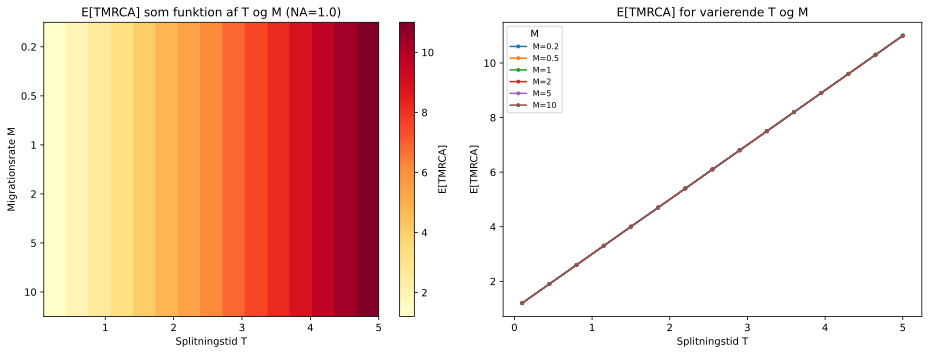

Observation:
- Høj M + stor T → lav E[TMRCA] (hurtig koalescens i migrations-epoket).
- Lav M + lav T → høj E[TMRCA] (migration er langsom, ingen tid at koalescere).
- For stor T mætter kurven: alle linjer har koalesceret i migrations-epoket.


In [10]:
T_grid = np.linspace(0.1, 5, 15)
M_grid = [0.2, 0.5, 1, 2, 5, 10]
NA_fixed = 1.0

E_matrix = np.zeros((len(M_grid), len(T_grid)))
for i, M_val in enumerate(M_grid):
    for j, T_val in enumerate(T_grid):
        im = build_im_model(2, 0, M=M_val, T=T_val, NA=NA_fixed)
        E_matrix[i, j] = im_expectation(im)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
im_plot = axes[0].imshow(E_matrix, aspect='auto', cmap='YlOrRd',
                          extent=[T_grid[0], T_grid[-1], len(M_grid)-0.5, -0.5])
plt.colorbar(im_plot, ax=axes[0], label='E[TMRCA]')
axes[0].set_yticks(range(len(M_grid)))
axes[0].set_yticklabels(M_grid)
axes[0].set_xlabel('Splitningstid T')
axes[0].set_ylabel('Migrationsrate M')
axes[0].set_title(f'E[TMRCA] som funktion af T og M (NA={NA_fixed})')

# Linjeplots\n",
for i, M_val in enumerate(M_grid):\
    axes[1].plot(T_grid, E_matrix[i, :], 'o-', ms=3, lw=1.5, label=f'M={M_val}')
    
axes[1].set_xlabel('Splitningstid T')
axes[1].set_ylabel('E[TMRCA]')
axes[1].set_title('E[TMRCA] for varierende T og M')
axes[1].legend(title='M', fontsize=8)
    
plt.tight_layout()
plt.show()
print("Observation:")
print("- Høj M + stor T → lav E[TMRCA] (hurtig koalescens i migrations-epoket).")
print("- Lav M + lav T → høj E[TMRCA] (migration er langsom, ingen tid at koalescere).")
print("- For stor T mætter kurven: alle linjer har koalesceret i migrations-epoket.")

## 7. JSFS for IM-modellen
    
JSFS for IM-modellen kombinerer bidrag fra de to epoker. I migrations-epoket kan linjer have efterkommere i begge populationer. I den ancestrale epoke er alle linjer i en samlet population og bidrager kun til kanterne (private i den forstand at ancestral-pop ikke kendes)

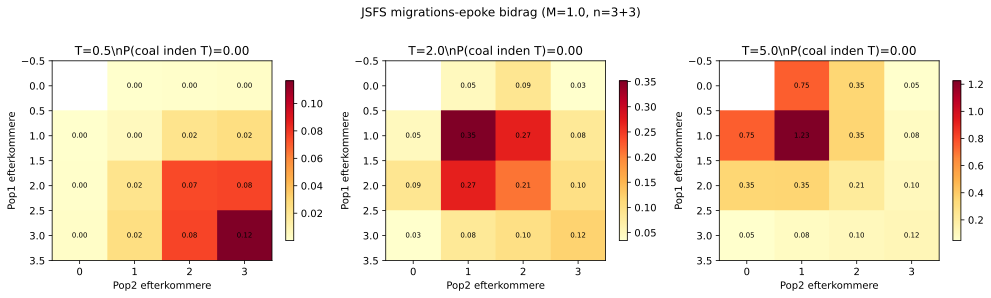

Observation:
- Stor T → mere grenlængde akkumuleret i migrations-epoket.
- JSFS'en viser det mønster der kun stammer fra migrationsepokens bidrag.
- Ancestral-epokets bidrag (ikke vist) bidrager til indre celler (delte).


In [11]:
def compute_im_jsfs(n1, n2, M, T, NA=1.0):
    """
    Beregn forventet grenlængde-bidrag per (pop1, pop2)-type for IM-modellen.

    Migrations-epoket bidrag beregnes via accumulated_occupancy(T).
    Ancestral-epoket bidrager kun til 'merged' varianter (begge pops).
    """
    g_mig = build_migration_phase(n1, n2, M=M, N1=1.0, N2=1.0)
    g_anc = build_ancestral_phase(n1 + n2, NA=NA)
    
    # Accumulated occupancy frem til T for migrations-grafen
    acc_T = np.array(g_mig.accumulated_occupancy(T))
    states_mig = g_mig.states()  # shape: (n_vert, 2)
    
    P_not_coal = 1.0 - g_mig.cdf(T)
    
    jsfs = np.zeros((n1 + 1, n2 + 1))
    
    # Migrations-epoket: reward = tid brugt i tilstand (pop1=i, pop2=j)
    for i in range(n1 + 1):
        for j in range(n2 + 1):
            if i == 0 and j == 0: continue
            reward = np.array([
                1.0 if (s[0] == i and s[1] == j) else 0.0
                for s in states_mig
            ])
            jsfs[i, j] += float(np.sum(acc_T * reward))
    
    # Ancestral-epoket: alle efterkommere er i begge pops (merged),
    # så vi tilføjer ancestral grenlængde til total-kolonnen
    # (dette er en forenkling — fuld JSFS kræver mere sofistikeret reward)
    E_anc = P_not_coal * g_anc.expectation()
    
    return jsfs, E_anc, P_not_coal
    
# JSFS for varierende T
T_vals_jsfs = [0.5, 2.0, 5.0]
n1, n2 = 3, 3
M_jsfs = 1.0
    
fig, axes = plt.subplots(1, len(T_vals_jsfs), figsize=(14, 4))
    
for ax, T_val in zip(axes, T_vals_jsfs):
    jsfs, E_anc, P_nc = compute_im_jsfs(n1, n2, M=M_jsfs, T=T_val)
    
    jsfs_plot = jsfs.copy()
    jsfs_plot[0, 0] = np.nan
    im_map = ax.imshow(jsfs_plot, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im_map, ax=ax, shrink=0.8)
    
    for i in range(n1 + 1):
        for j in range(n2 + 1):
            if not np.isnan(jsfs_plot[i, j]):
                ax.text(j, i, f'{jsfs_plot[i,j]:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if jsfs_plot[i,j] > jsfs_plot.max()*0.6 else 'black')
    
    ax.set_xlabel('Pop2 efterkommere')
    ax.set_ylabel('Pop1 efterkommere')
    ax.set_title(f'T={T_val}\\nP(coal inden T)={1-P_nc:.2f}')
    
plt.suptitle(f'JSFS migrations-epoke bidrag (M={M_jsfs}, n={n1}+{n2})', y=1.02)
plt.tight_layout()
plt.show()
print("Observation:")
print("- Stor T → mere grenlængde akkumuleret i migrations-epoket.")
print("- JSFS'en viser det mønster der kun stammer fra migrationsepokens bidrag.")
print("- Ancestral-epokets bidrag (ikke vist) bidrager til indre celler (delte).")

## CDF-komposition: direkte visualisering af epoker

**Eksperiment:** Visualiser, hvordan CDF'en sammensættes af bidrag fra de to epoker — med tydelig markering af splitningstidspunktet $T$.

In [ ]:
# CDF-komposition for en specifik model
T_demo, M_demo, NA_demo = 2.5, 1.5, 2.0
im_demo = build_im_model(2, 0, M=M_demo, T=T_demo, NA=NA_demo)
    
t_plot = np.linspace(0, 15, 600)
cdf_vals = im_cdf(im_demo, t_plot)
pdf_vals = im_pdf(im_demo, t_plot)
    
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
# PDF
axes[0].plot(t_plot, pdf_vals, 'steelblue', lw=2, label='IM-model PDF')
axes[0].axvline(T_demo, color='red', ls='--', lw=1.5, label=f'T={T_demo}')
axes[0].fill_between(t_plot[t_plot <= T_demo],
                     pdf_vals[t_plot <= T_demo],
                     alpha=0.3, color='orange', label='Migrations-epoke')
axes[0].fill_between(t_plot[t_plot > T_demo],
                     pdf_vals[t_plot > T_demo],
                     alpha=0.3, color='green', label='Ancestral epoke')
axes[0].set_xlabel('TMRCA')
axes[0].set_ylabel('Tæthed')
axes[0].set_title(f'IM-model PDF (T={T_demo}, M={M_demo}, NA={NA_demo})')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 15)

# CDF med epoke-bidrag
axes[1].plot(t_plot, cdf_vals, 'steelblue', lw=2)
axes[1].axvline(T_demo, color='red', ls='--', lw=1.5, label=f'T={T_demo}')
P_coal = im_demo['P_coal_before_T']
axes[1].axhline(P_coal, color='orange', ls=':', lw=1.5,
                label=f'P(coal inden T)={P_coal:.2f}')
axes[1].axhline(1.0, color='gray', ls=':', lw=1)
axes[1].set_xlabel('TMRCA')
axes[1].set_ylabel('F(t)')
axes[1].set_title('CDF med epokemarkering')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 15)
    
plt.tight_layout()
plt.show()
    
E_val = im_expectation(im_demo)
print(f"Model: T={T_demo}, M={M_demo}, NA={NA_demo}")
print(f"E[TMRCA] = {E_val:.4f}")
print(f"P(coal inden T) = {P_coal:.4f}")
print(f"P(coal efter T) = {1-P_coal:.4f}")

## Opsummering

| Eksperiment | Nøgleresultat |
|---|---|
| PDF vs. T | 'Spring' i PDF ved T; tydelig diskontinuitet |
| Epoke-bidrag | Migrations-epoket dominerer for stor T og stor M |
| IM vs. two-island | Adskillelig i PDF'en via springet ved T |
| Parameterrum (T,M) | Høj M + stor T → lav TMRCA |
| JSFS | Migrations-bidrag vokser med T |

**Næste notebook:** 06_ghost_populations.ipynb — ghost populations i IM-kontekst.